In [1]:
import os
os.chdir('../../../..')

In [24]:
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from umap import UMAP

from src.datasets import QM9Dataset
from scripts.materials_project.euclidean_evaluation_pipeline import build_invariant_matrix
from src.helper_functions import create_chemiscope_viewer

In [26]:
qm9 = QM9Dataset(limit=25000, stratify_by=['num_atoms', 'gap'], sampling_strategy="stratified")
df = qm9.load()

2026-04-05 17:20:29.306 | INFO     | src.datasets:load:460 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-04-05 17:20:29.609 | INFO     | src.datasets:_sample_qm9_df:576 - QM9 sampling complete: strategy=stratified, requested_limit=25000, returned_rows=25000.
2026-04-05 17:20:29.610 | INFO     | src.datasets:_add_requested_descriptors:123 - Applying requested QM9 descriptors to sampled dataframe (rows=25000).
2026-04-05 17:20:29.610 | INFO     | src.datasets:_add_requested_descriptors:148 - No new descriptor columns added (already present or none requested).


In [27]:
features_1 = ['ea']
features_2 = ['en', 'ion_en']
features_3 = ['en']
features_4 = ['ion_en', 'z', 'en']

raw_matrix = build_invariant_matrix(df, aggregated=True, feature_keys=features_1)
scaler = StandardScaler()
scaled_matrix = scaler.fit_transform(raw_matrix)
labels = KMeans(n_clusters=6, random_state=42, n_init='auto').fit_predict(scaled_matrix)
df = df.with_columns(pl.Series("cluster_label", labels))

sil = silhouette_score(scaled_matrix, labels)
db = davies_bouldin_score(scaled_matrix, labels)
print(f"Silhouette Score: {sil:.4f}")
print(f"Davies-Bouldin Score: {db:.4f}")

Silhouette Score: 0.5146
Davies-Bouldin Score: 0.6473


In [19]:
reducer = 'PCA'
create_chemiscope_viewer(df, scaled_matrix, labels=labels, reduction_method=reducer)

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

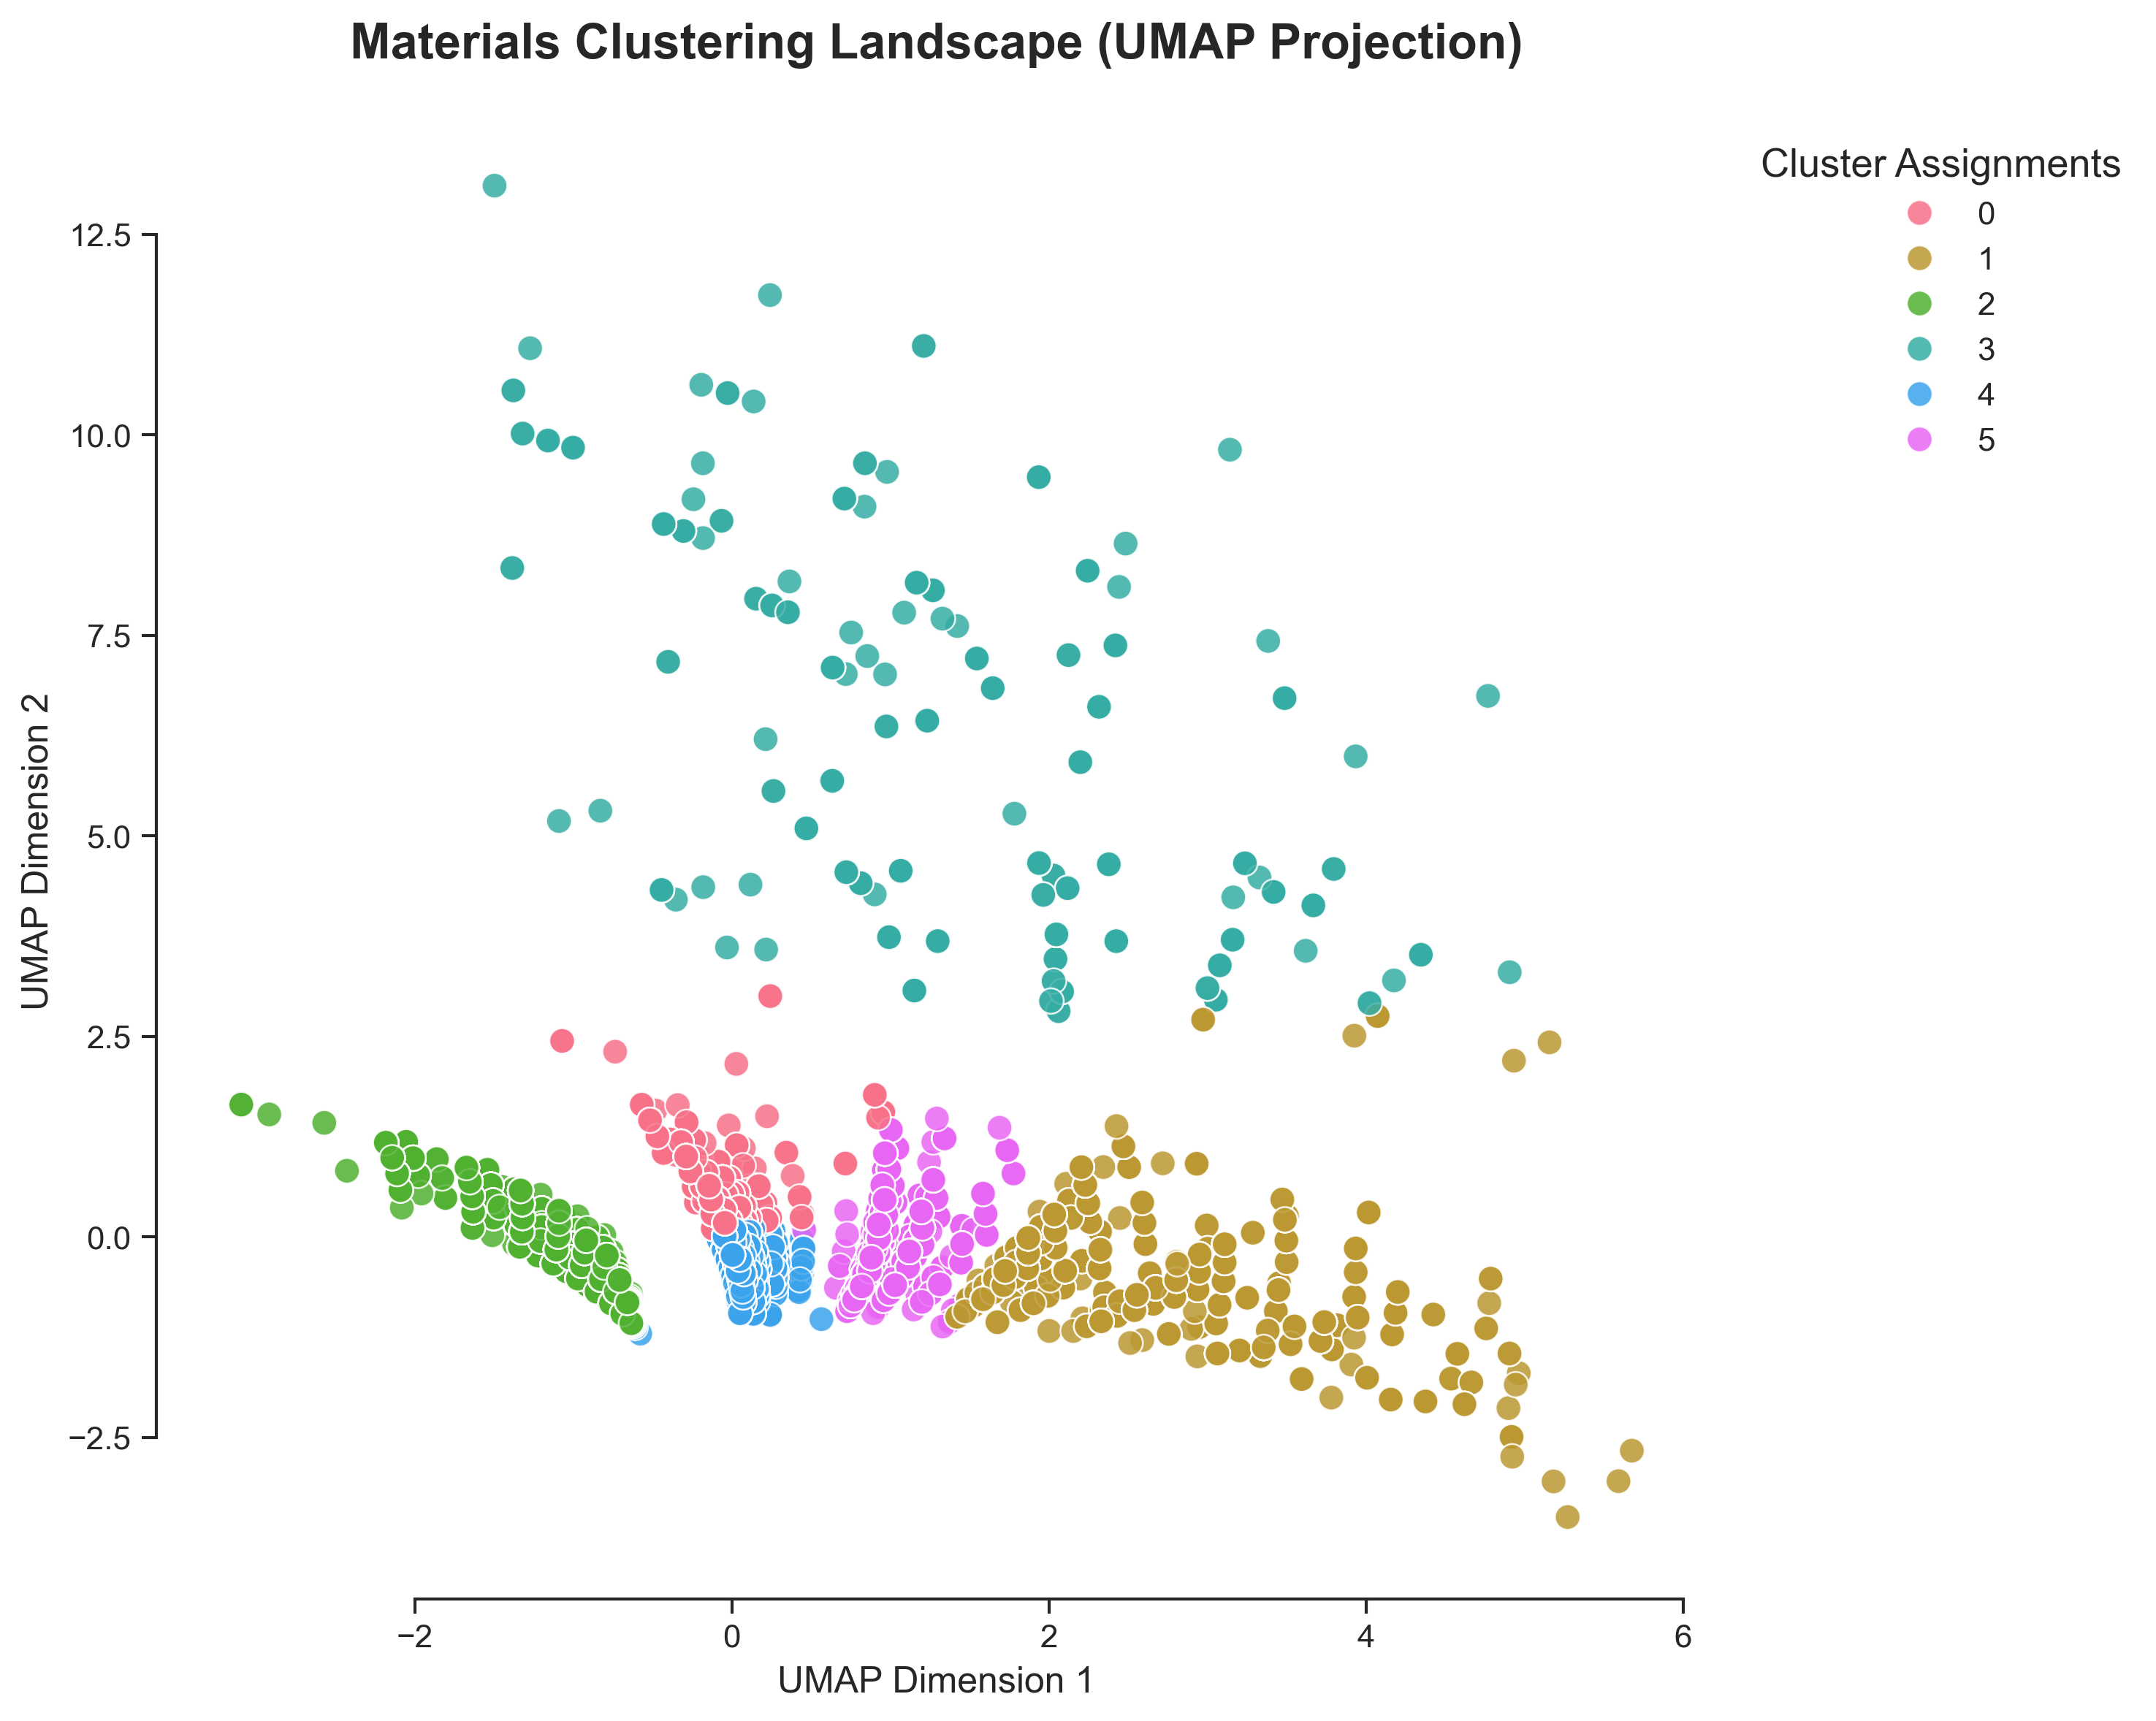

In [28]:
# 1. Setup UMAP (added n_neighbors and min_dist for better aesthetic tuning)
# umap_reducer = UMAP(n_components=2, metric='euclidean', n_neighbors=15, min_dist=0.1, random_state=42)
# umap_embedding = umap_reducer.fit_transform(scaled_matrix)

# pca reducer
pca_reducer = PCA(n_components=2, random_state=42)
pca_embedding = pca_reducer.fit_transform(scaled_matrix)

# 2. Setup Professional Plot Style
sns.set_theme(style="ticks", context="paper", font_scale=1.2)
fig, ax = plt.subplots(figsize=(10, 8), dpi=300) # High DPI makes it crisp for papers/presentations

# Convert labels to numpy array for boolean masking
labels = np.array(labels)
unique_labels = np.unique(labels)
n_clusters = len([l for l in unique_labels if l != -1])

# 3. Plot Noise First (so it stays in the background!)
noise_mask = (labels == -1)
if noise_mask.any():
    ax.scatter(
        pca_embedding[noise_mask, 0], 
        pca_embedding[noise_mask, 1], 
        c='#B0B0B0',        # Soft silver/grey
        s=15,               # Smaller size
        alpha=0.4,          # Highly transparent
        label='Noise (-1)',
        edgecolors='none'
    )

# 4. Plot the Valid Clusters
cluster_mask = (labels != -1)
if cluster_mask.any():
    # Use a vibrant, visually pleasing palette
    palette = sns.color_palette("husl", n_clusters)
    
    sns.scatterplot(
        x=pca_embedding[cluster_mask, 0], 
        y=pca_embedding[cluster_mask, 1], 
        hue=labels[cluster_mask], 
        palette=palette,
        s=70,               # Larger size for valid points
        alpha=0.85,         # Slight transparency to show density
        edgecolor='white',  # Adds a crisp outline to overlapping points
        linewidth=0.6,
        ax=ax,
        legend='full'
    )

# 5. Typography and Labels
ax.set_title('Materials Clustering Landscape (UMAP Projection)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('UMAP Dimension 1', fontsize=12, fontweight='medium')
ax.set_ylabel('UMAP Dimension 2', fontsize=12, fontweight='medium')

# 6. Clean up the box/axes (Despine)
sns.despine(trim=True, offset=5)

# 7. Legend Formatting
# Move legend outside the plot, remove its ugly box
ax.legend(title="Cluster Assignments", 
          bbox_to_anchor=(1.02, 1), 
          loc='upper left', 
          frameon=False, 
          title_fontsize='13')

plt.tight_layout()

# Save it as a high-quality image (optional)
plt.savefig("figures/qm9/clustering/kmeans/pca_clusters.png", dpi=300, bbox_inches='tight')

plt.show()